In [30]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
import seaborn as sns

In [31]:
df = pd.read_csv("reg.csv")
df

,f1,f2,f3,f4,f5,target
0,1000,150,30,85,6,12.0
1,800,150,30,85,6,11.0
2,950,200,40,90,5,11.5
3,1500,200,40,90,10,15.0
4,500,100,15,45,3,7.0
5,700,120,25,60,5,10.0
6,1000,150,30,85,6,12.0
7,800,150,30,85,6,11.0
8,950,200,40,90,5,11.5
9,1500,200,40,90,10,15.0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      30 non-null     int64  
 1   f2      30 non-null     int64  
 2   f3      30 non-null     int64  
 3   f4      30 non-null     int64  
 4   f5      30 non-null     int64  
 5   target  30 non-null     float64
dtypes: float64(1), int64(5)
memory usage: 1.5 KB


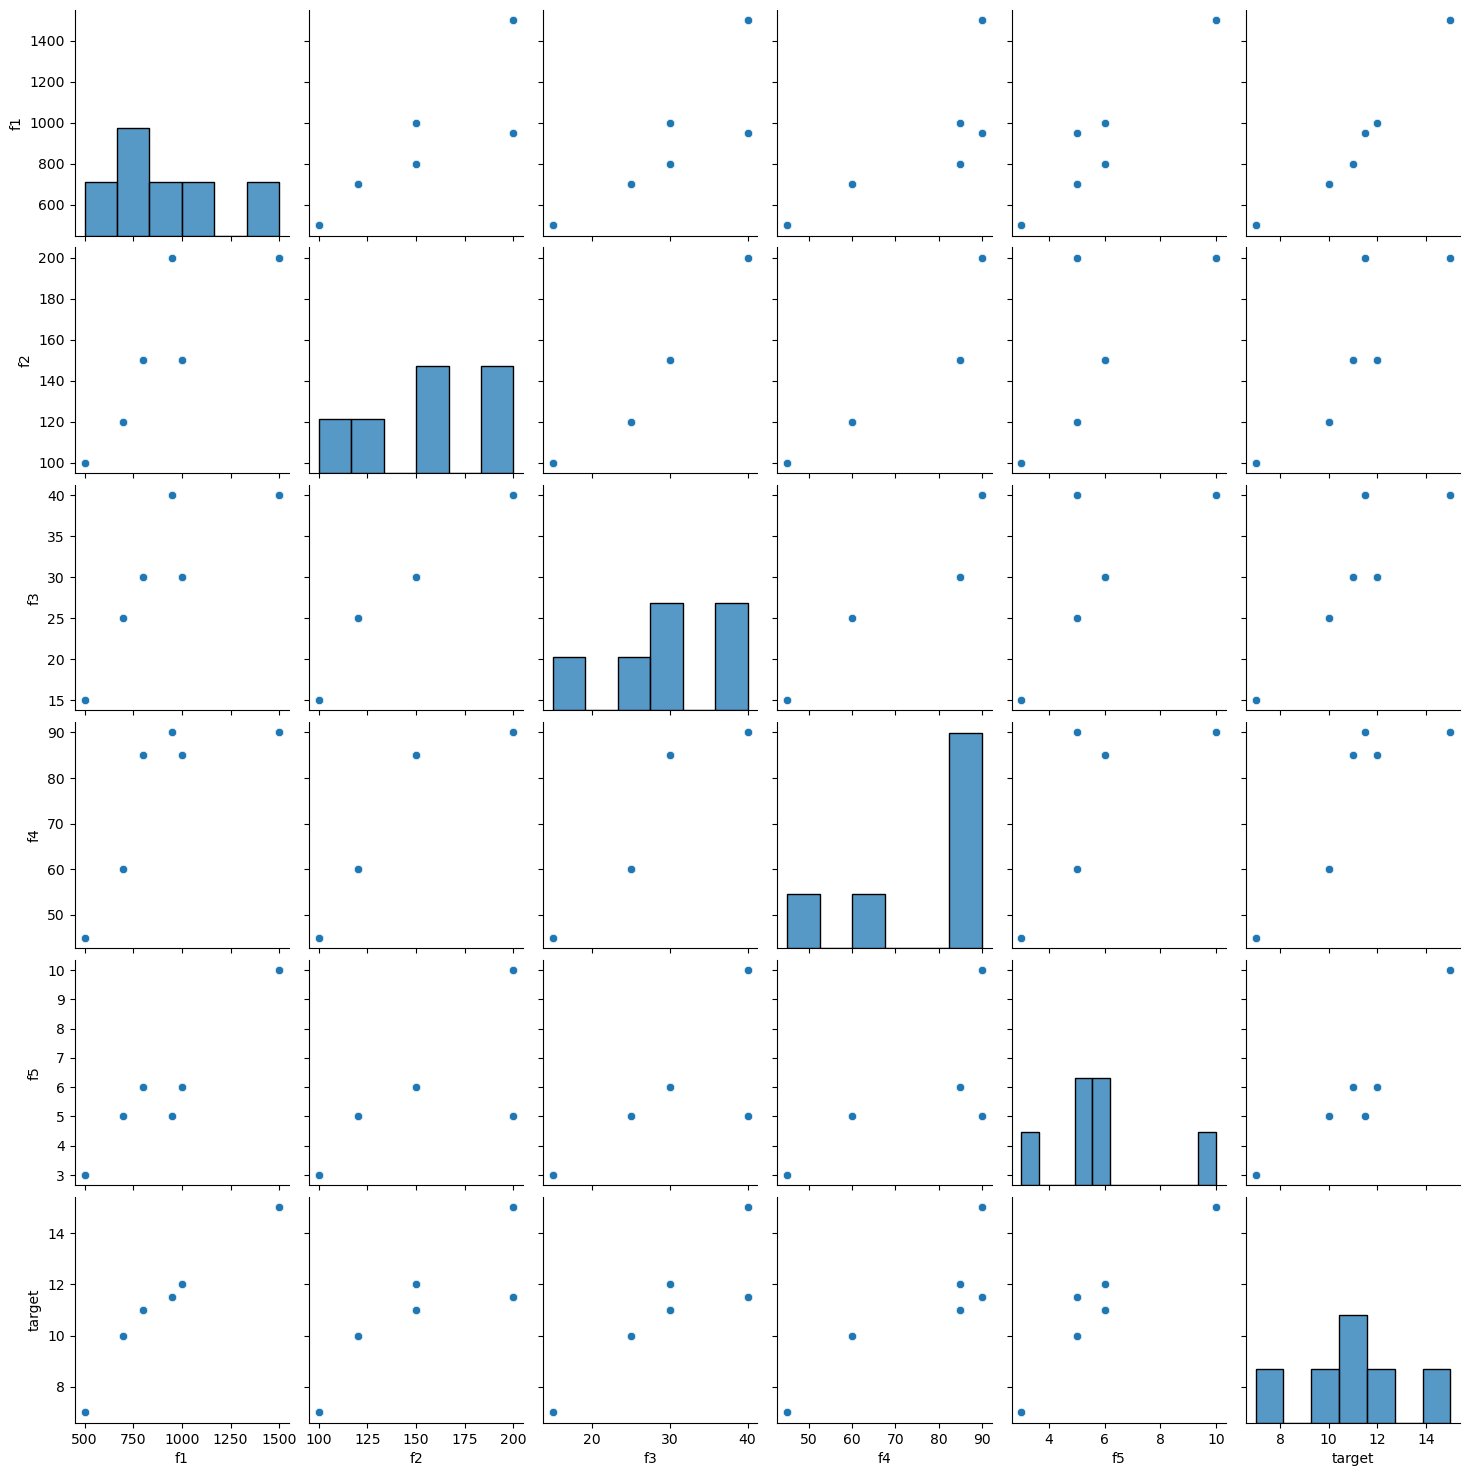

In [33]:
sns.pairplot(df)

<Axes: >

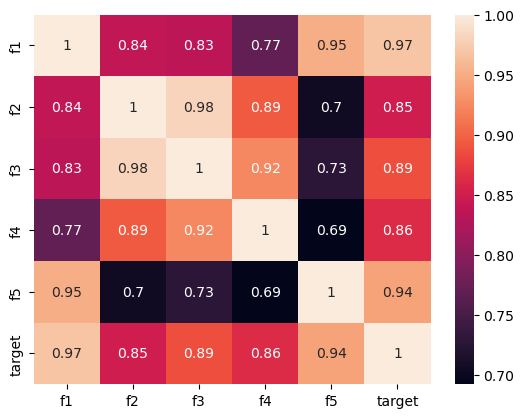

In [49]:
sns.heatmap(df[["f1","f2","f3","f4","f5","target"]].corr(), annot =True)

In [42]:
x = df[["f1","f2","f3","f4","f5"]]
y = df["target"]

In [43]:
model = LinearRegression()

In [44]:
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
coff = model.coef_
coff

array([ 0.005     , -0.05034483,  0.22724138,  0.02896552,  0.15      ])

In [46]:
inter_cept = model.intercept_
inter_cept

np.float64(4.372413793103436)

In [47]:
lasso = Lasso(alpha = 0.1)
lasso.fit(x,y)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [48]:
pred = lasso.coef_
pred

array([ 0.00622311, -0.04675985,  0.19112112,  0.03421432,  0.        ])

In [50]:
from sklearn.linear_model import Ridge

In [56]:
ridge = Ridge(alpha=1)
ridge.fit(x,y)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [61]:
r = ridge.coef_

LASSO


<BarContainer object of 5 artists>

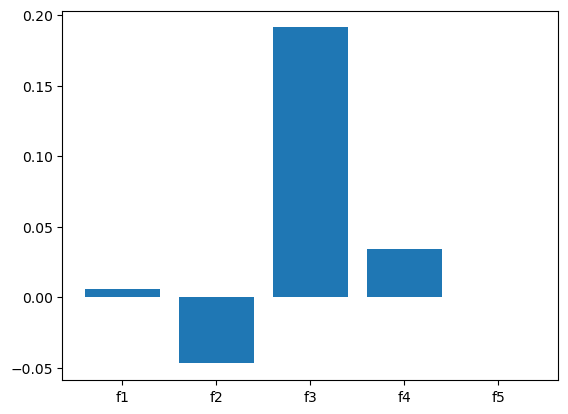

In [72]:
import matplotlib.pyplot as plt

coff_names = ["f1","f2","f3","f4","f5"]
plt.bar(coff_names,pred)

RIDGE

<BarContainer object of 5 artists>

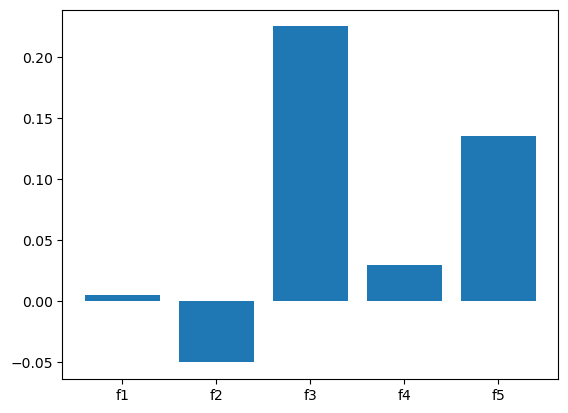

In [64]:
coff_names = ["f1","f2","f3","f4","f5"]
plt.bar(coff_names,r)

LINEAR REGRESSION

<BarContainer object of 5 artists>

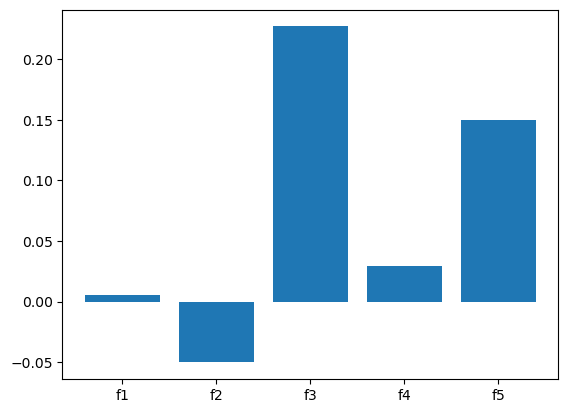

In [65]:
coff_names = ["f1","f2","f3","f4","f5"]
plt.bar(coff_names,coff)

In [67]:
from sklearn.linear_model import ElasticNet
model = ElasticNet(alpha=1.0, l1_ratio=0.5)
model.fit(x,y)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [68]:
elas = model.coef_
elas

array([ 0.00628451, -0.00852274,  0.        ,  0.04682796,  0.        ])

ELASTIC BAR COMPARISION

<BarContainer object of 5 artists>

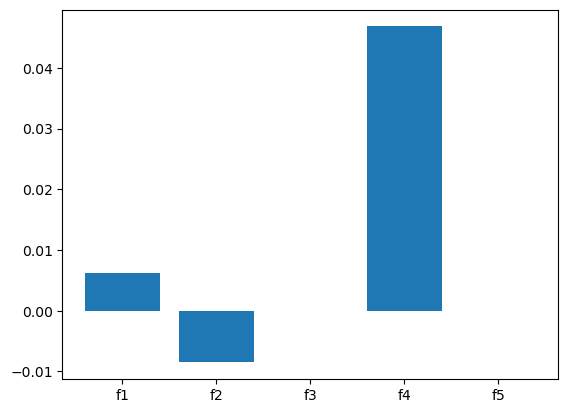

In [69]:
coff_names = ["f1","f2","f3","f4","f5"]
plt.bar(coff_names,elas)